# **Atividade Prática**
<font size=3>

- **Tema:** métodos baseados em árvores.
- **Prazo de entrega:** 14 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

### **1. Questão:** 
<font size=3>

Com base no *dataset* de [classificação de dígitos](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html), realize os seguintes passos:

1. **Importe os dados** nas variáveis de atributos (`X`) e alvo (`y`). Este *dataset* apresenta imagens de dígitos manuscritos em formato de *arrays* unidimensionais e suas "etiquetas" como números interios de 0 a 9;  

2. **Escreva** em uma **cálula _markdown_** do que se tratam os atributos dos dados de entrada;

3. Plote a imagem de um dígitos utilizando a função [`imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html). Aqui será necessário fazer o *reshape* da imagem $(64,)$ para $(8\times 8)$;

4. Para o modelo [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) se faz necessário pré-processamento dos dados de entrada e alvo? **Justifique sua resposta** em uma **cálula _markdown_**.

5. Treine este modelo, utilizando o [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) para afinar os hyperparâmetros de poda. **Imprima na tela** os melhores valores de hiperparâmetros;

5. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. Existem características em comuns nos dois dígitos de melhor classificação? **Justifique sua resposta** em uma **cálula _markdown_**. 


## Resposta parte 2:

A entrada dos atributos representados pela variavel x no dataset são as representações numericas em forma de imagem dos numeros de 0 a 9 onde cada numero é representodo por um vetor de 64D em que temos cada valor como a representação como se fosse um pixel na escala de cinza para forma o numero que queremos 

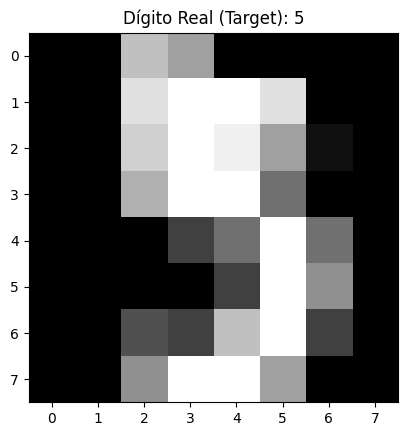

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_digits
import matplotlib.pyplot as plot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

dataset = load_digits()
x = pd.DataFrame(dataset.data)
y = dataset.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42,stratify=y)


numero = 5
img_matrix = x.iloc[numero].values.reshape(8, 8)
plot.imshow(img_matrix, cmap='gray')
plot.title(f"Dígito Real (Target): {y[numero]}") 
plot.show()



## Resposta para 4:

Nesse modelo não é precisso passar por tratamento de pre-processamento como de fazer normalização escalonamento mas sim conversão caso nosssa entradas se forem "palavras", ordenação e precisa remover elementos NAN, ou seja seria transformar categorias em numeros

Melhores Hiperparâmetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}

Classificação:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        54
           1       0.83      0.78      0.80        55
           2       0.80      0.81      0.80        53
           3       0.89      0.85      0.87        55
           4       0.85      0.87      0.86        54
           5       0.91      0.93      0.92        55
           6       0.94      0.89      0.91        54
           7       0.81      0.89      0.85        54
           8       0.69      0.79      0.74        52
           9       0.84      0.76      0.80        54

    accuracy                           0.85       540
   macro avg       0.85      0.85      0.85       540
weighted avg       0.85      0.85      0.85       540



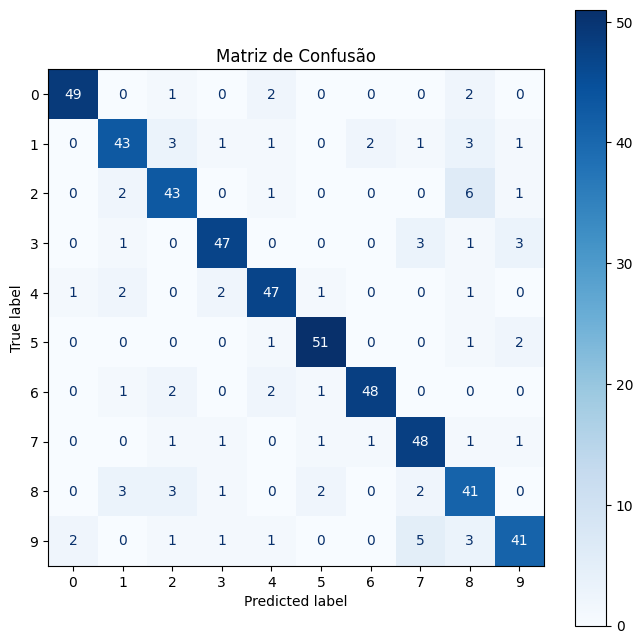

In [33]:


model = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}


grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)


print(f"Melhores Hiperparâmetros: {grid_search.best_params_}")


best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

print("\nClassificação:")
print(classification_report(y_test, y_pred))


fig, ax = plot.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plot.title("Matriz de Confusão")
plot.show()

## Resposta para o 6:

O numeros que sa sairam melhor o f1-score foram os numeros 0e 6 foram o 0 (0.96) e o 6 (0.93), com isso podemos tirar que por ele terem formato com um burraco no centro de um circulo fez com que isso facilitacesse muito provalvelmente a sua indentificação 

### **2. Questão:** 
<font size=3>

Com base no *dataset* de [Classificação de Poemas](https://www.kaggle.com/datasets/ramjasmaurya/poem-classification-nlp), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:

1. Importe o *dataset* e defina os poemas como a variável de atributos e os gêneros como a variável alvo;

2. Utilize a função [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) para quebrar os poemas em listas de palavras, e transformar estas em representações numéricos, considerando as variáveis:
    <font size=2>

    ```python
    vectorizer = TfidfVectorizer(lowercase=True, 
                                 stop_words="english", 
                                 token_pattern=r"\b[a-zA-Z]{2,}\b", 
                                 min_df=2))
                                 
    ```

3. **Escreva** em uma **célula _markdown_** do que se trata os atributos dos dados de entrada;

4. Com o [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), faça o encadeamento do vetorizador com o modelo [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html);

5. **Escreva** em uma **célula _markdown_** as características do algoritmo do *random forest* que mitigam o *overfitting*;

6. Encontre os melhores hiperparâmetros de poda e número de árvores com o  [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

7. Para plotar os atributos de maior importância, adapte as seguintes linhas de código na sua implementação:
    <font size=2>

    ```python
    best_pipe = random_search.best_estimator_
    
    vectorizer = best_pipe.named_steps['vectorizer']
    random_forest = best_pipe.named_steps['model']
    
    feature_names = vectorizer.get_feature_names_out()
    feature_importances = random_forest.feature_importances_
    ```
    <font size=3>
    <br>
        
    Com os *arrays* `feature_names` e `feature_importance`, faça o gráfico de barras das 10 palavras mais importantes para as classificações (ver **_notebook_ 10** para o gráfico de barras).

8. Utilize a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
    

## Resposta para o 3:

Nesse modelo a entrada das features são as represetações de forma numerica das palavras individuais que foram extraidas dos poemas usando TfidfVectorizer onde o texto de cada poema é transformado em uma matriz que cada coluna é a representação de um unico termo que aparece no conjunto dos dados do dataset. 



In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

dataset = pd.read_csv("/content/drive/MyDrive/5 semestre /Aprendizado de maquina supervisionado/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/poem_classification.csv")
dataset.head()
dataset = dataset.dropna(subset=['Poem', 'Genre'])
x = dataset["Poem"]
y= dataset["Genre"]

vectorizer = TfidfVectorizer(lowercase=True, 
                            stop_words="english", 
                            token_pattern=r"\b[a-zA-Z]{2,}\b", 
                            min_df=2)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42,stratify=y)


pipe = Pipeline([("vectorizer", vectorizer),("model", RandomForestClassifier(random_state=42))])
pipe


Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(min_df=2, stop_words='english',
                                 token_pattern='\\b[a-zA-Z]{2,}\\b')),
                ('model', RandomForestClassifier(random_state=42))])

## Resposta para o 5:

O random florest consegue reduzir o overfinting por conta que ele e capaz de combinar duas tecnicas, boostrap, aleatoriedade de atributos em quem o boostrap age como um criador de arvores de decisao independetes que permite repetição e atravez da media reduz a variancia ja a aleatoriedade de atributos como atravez dessa tecnica o algoritmo se torna capaz de decidir como vai ser a melhor divisao desconsiderando o atributo mais dominate pois ele escolhe com base em um subconjunto de atributos empede que por exemplo nessa caso uma palavra dominante mande como que vai ser a estrutura da arvore fornçando o modelo a olhar tambem para outros termos relevantes, o que faz com que reduza os overfinttigs

Melhores parâmetros: {'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_depth': 10}


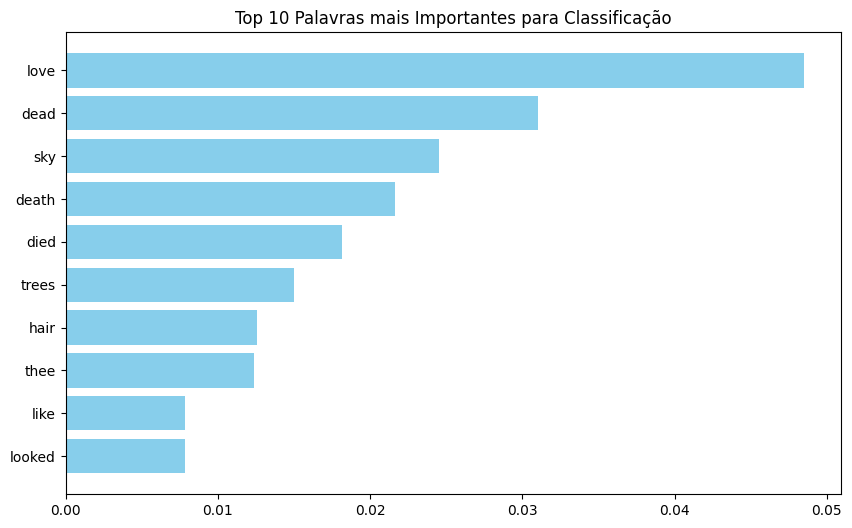


Relatório de Classificação:
              precision    recall  f1-score   support

   Affection       0.50      0.40      0.44        73
       Death       0.35      0.25      0.29        73
 Environment       0.45      0.49      0.47        76
       Music       0.35      0.49      0.41        75

    accuracy                           0.41       297
   macro avg       0.41      0.41      0.40       297
weighted avg       0.41      0.41      0.40       297



In [35]:
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=5, cv=3, random_state=42, n_jobs=-1)
random_search.fit(x_train, y_train)

print(f"Melhores parâmetros: {random_search.best_params_}")



best_pipe = random_search.best_estimator_
vectorizer = best_pipe.named_steps['vectorizer']
random_forest = best_pipe.named_steps['model']

feature_names = vectorizer.get_feature_names_out()
feature_importances = random_forest.feature_importances_



df_importances = pd.DataFrame({'word': feature_names, 'importance': feature_importances})
df_importances = df_importances.sort_values(by='importance', ascending=False).head(10)



plot.figure(figsize=(10, 6))
plot.barh(df_importances['word'], df_importances['importance'], color='skyblue')
plot.gca().invert_yaxis()
plot.title("Top 10 Palavras mais Importantes para Classificação")
plot.show()

y_pred = best_pipe.predict(x_test)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

## Resposta para o 8:

O que podemos analizar é que o modelo esta capaz de entender porem de forma muito basicas podendo captura os temas atravez das palavras chaves porem ele esta sofrente pela questao de sobrepor vocabulario entre cada genero ja para os indicados que o modelo não encontrou termos exclusivos suficiente para diferenciá-lo. Já Death, apesar de ter palavras óbvias como "death" e "dead", sofreu com baixo recall (0.40),sugerindo que o modelo falha quando o tema é abordado de forma metafórica.

### **3. Questão:** 
<font size=3>

Com base no *dataset* de [Performance Acadêmica](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:

1. Importe o *dataset* e defina o atributo `exam_score` como a variável alvo para **regressão**, e os demais atributos como entrada do modelo;

2. Utilize o [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) para encadear o pré-processamento [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) dos atributos categóricos com o modelo [`GradientBoostingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html). **Dica:** para que apenas os atributos categóricos passem pelo pré-processamento, e as demais não, utilize o [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) com a variável `remainder = "passthrough"`;

3. **Escreva** em uma **célula _markdown_** as semelhanças e diferenças entre o modelo *gradient booting* e o *random forest*;

4. Plote o gráfico de barras da importâncias dos atributos e, com base nele, **escreva** em uma **célula _markdown_** um breve relatório sobre quais atributos são mais relevantes e os menos relevantes. Desenvolva uma análise interpretativa do porquê esses atributos se destacam desta forma.

5. Para avaliação do modelo, **imprima na tela** o valores de MSE e $R^2$ entre os dados de predição e teste.


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

dataset = pd.read_csv("/content/drive/MyDrive/5 semestre /Aprendizado de maquina supervisionado/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/student_habits_performance.csv")
dataset.head()

x = dataset.drop(columns=["exam_score"])
y = dataset["exam_score"]

categorical_cols = x.select_dtypes(include=['object']).columns.tolist()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), categorical_cols)
    ],
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OrdinalEncoder(),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

## Resposta para o 3:

Nas semelhanças os dois aloritmos sao de Ensembre Learning e baseados em arvores de decisao, ja que em ambos é combinado varias arvores individuas para gerar uma predição final bem precisa e robusta, porem nas diferenças temos que os metodos de contrução sáo bem diferente pois enquanto o random florest cria arvores independetes em paralelo o gradient boosting constroe as arvores de fomra sequencial em que cada nova arvore corrige os erros da anterior e que no metodo do random forest setorna maravilho para reduzir a variancia.
        

MSE: 30.4208
R² Score: 0.8879


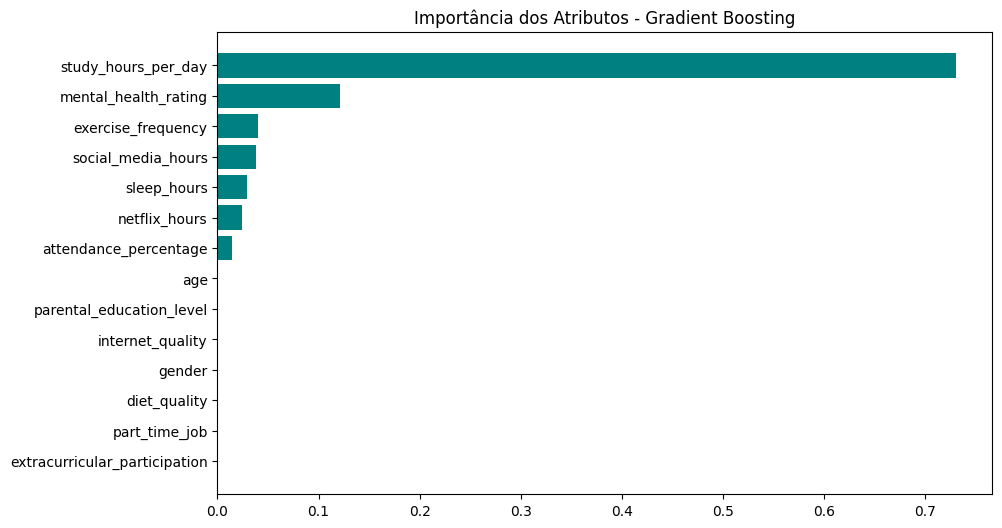

In [37]:
pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

feature_names = categorical_cols + [col for col in x.columns if col not in categorical_cols]
importances = pipe.named_steps['model'].feature_importances_

df_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_importance = df_importance.sort_values(by='importance', ascending=False)

plot.figure(figsize=(10, 6))
plot.barh(df_importance['feature'], df_importance['importance'], color='teal')
plot.gca().invert_yaxis()
plot.title("Importância dos Atributos - Gradient Boosting")
plot.show()

## Resposta para o 4:

Com base no que foi plotado a analizando o primeiro o codigo temos que o atributo mais relevante é o study_hours_per_day com um peso de 0.7, ja os atributos secundarias mostra que não é o unico caminho pois fatores com o frequencia de exercicios, ja em atributos menos relevantes o fator como genero, idade, qualidade da dieta e a participação cada uma de forma mais simpliicada em praticas extracurriculares demonstram a importancia para que apresentem ipara esse modelo expecifico


